In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr
import re
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

In [2]:
enriched_df = pd.read_csv("C:/Users/taiwoajayi/OneDrive - University of Arizona/NeededforreconstructOutput.csv", skiprows=0)
enriched_df

,Time_Start,Sodium,Ammonium,Magnesium,MSA,Bromide,Chloride,Nitrate,Oxalate,Phthalate,...,ICP_Zr,ICP_Mo,ICP_Cd,ICP_Sn,ICP_Cs,ICP_Ba,ICP_Pb,nss_Sulfate,nssK,nssCa
0,2/14/2020 17:50,17520.0,2187.0,1984.0,9.9,8.6,28480.0,10630.0,48.6,103.0,...,0.0155,0.3382,1.9446,0.2603,0.0075,1.3324,0.4185,2933.0,0.0,883.2
1,2/14/2020 18:00,63880.0,2910.0,7494.0,6.5,78.5,108200.0,17660.0,304.0,3.5,...,0.0890,0.3810,43.7100,0.5880,0.0120,9.3190,5.0560,3417.8,0.0,139.6
2,2/14/2020 18:18,38690.0,2006.0,4666.0,3.0,32.7,66040.0,12300.0,460.0,1.7,...,0.0895,0.3818,43.4221,0.5822,0.0119,9.3315,5.0262,2815.6,0.0,537.8
3,2/14/2020 19:03,117100.0,6136.0,13950.0,3.6,87.7,198100.0,35660.0,320.8,8.1,...,0.0906,0.3837,42.7155,0.5678,0.0118,9.3622,4.9530,7747.6,0.0,260.2
4,2/15/2020 17:30,26550.0,1313.0,3086.0,20.2,8.0,41750.0,17280.0,136.2,2.9,...,0.1250,0.4400,21.5700,0.1390,0.0080,10.2800,2.7630,2155.0,0.0,296.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,6/14/2022 14:53,247.1,300.9,9.5,117.5,4.0,310.8,163.2,17.8,2.8,...,0.0041,0.1012,0.3360,0.0653,0.0042,0.7405,0.0084,209.2,407.6,131.1
531,6/14/2022 14:56,465.8,332.8,9.4,117.5,4.0,563.9,221.7,17.4,5.7,...,0.0084,0.1012,0.1321,0.0361,0.0040,1.2690,0.0094,319.1,318.0,132.8
532,6/14/2022 15:01,548.8,381.0,26.2,117.5,4.0,708.1,299.1,22.6,4.7,...,0.0106,0.2134,0.2500,0.0726,0.0020,1.7300,0.0152,510.9,266.2,225.0
533,6/14/2022 15:08,1073.0,587.4,128.0,117.5,4.0,1566.0,592.2,42.8,8.0,...,0.0122,0.2347,0.3073,0.0677,0.0025,1.9926,0.0171,726.1,0.0,670.1


In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# -----------------------------
# 1) Build X (species) and y (total mass)
# -----------------------------
df = enriched_df.copy()

time_col = "Time_Start"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# species columns = everything except Time_Start
species_cols = [c for c in df.columns if c != time_col]

# Ensure numeric species columns
df[species_cols] = df[species_cols].apply(pd.to_numeric, errors="coerce")

# Option for missing values:
# (A) If NaNs mean "not measured / below detection", you might want fillna(0).
# (B) If NaNs mean "unknown", consider imputation instead.
df[species_cols] = df[species_cols].fillna(0.0)

# Total solute mass row-wise (your target)
df["Total_Mass"] = df[species_cols].sum(axis=1)

# Drop rows with bad timestamps if needed
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

X = df[species_cols].copy()
y = df["Total_Mass"].copy()

print("Rows:", len(df), "Num species:", len(species_cols))
print("Target summary:\n", y.describe())


Rows: 535 Num species: 31
Target summary:
 count    5.350000e+02
mean     1.695380e+05
std      3.321270e+05
min      1.212128e+03
25%      2.074010e+04
50%      6.209202e+04
75%      1.640121e+05
max      3.318648e+06
Name: Total_Mass, dtype: float64


In [4]:
def cv_report(model, X, y, n_splits=5):
    """
    TimeSeriesSplit keeps ordering so you don't leak future into past.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    }
    out = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1, return_train_score=False)
    report = {
        "R2 (mean)": out["test_r2"].mean(),
        "MAE (mean)": -out["test_mae"].mean(),
        "RMSE (mean)": -out["test_rmse"].mean(),
    }
    return report


In [5]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = Pipeline(steps=[
    ("scaler", StandardScaler()),  # requested scaling
    ("model", GradientBoostingRegressor(
        random_state=42,
        loss="squared_error"
    ))
])

print("GBRT CV:", cv_report(gbrt, X, y, n_splits=5))

# Fit on full dataset for a single global importance ranking
gbrt.fit(X, y)

# Permutation importance is model-agnostic and usually more reliable than impurity importances
pi = permutation_importance(
    gbrt, X, y,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp = pd.DataFrame({
    "species": species_cols,
    "perm_importance_mean": pi.importances_mean,
    "perm_importance_std": pi.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop species by permutation importance (GBRT):")
print(imp.head(15).to_string(index=False))


GBRT CV: {'R2 (mean)': 0.9575647787634874, 'MAE (mean)': 16760.719711108984, 'RMSE (mean)': 53677.42711513872}

Top species by permutation importance (GBRT):
    species  perm_importance_mean  perm_importance_std
   Chloride              1.151960         4.266028e-02
     Sodium              0.179517         6.451743e-03
    Nitrate              0.001834         8.971722e-05
nss_Sulfate              0.001424         9.874926e-05
  Magnesium              0.000445         1.601726e-05
        MSA              0.000082         3.350510e-05
     ICP_Sr              0.000064         5.770521e-06
     ICP_As              0.000054         2.563909e-05
      ICP_V              0.000053         2.295973e-05
  Phthalate              0.000048         2.407763e-05
     ICP_Cu              0.000026         1.394035e-05
     ICP_Pb              0.000012         5.102629e-06
      nssCa              0.000007         1.283442e-06
     ICP_Co              0.000005         9.245783e-07
   Ammonium      

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = Pipeline(steps=[
    ("scaler", StandardScaler()),  # scaling still fine (even if not required for trees)
    ("model", HistGradientBoostingRegressor(
        random_state=42,
        max_depth=None,
        learning_rate=0.05,
        max_iter=500
    ))
])

print("HistGB CV:", cv_report(hgb, X, y, n_splits=5))

hgb.fit(X, y)
pi = permutation_importance(hgb, X, y, n_repeats=30, random_state=42, n_jobs=-1)

imp_hgb = pd.DataFrame({
    "species": species_cols,
    "perm_importance_mean": pi.importances_mean,
    "perm_importance_std": pi.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop species by permutation importance (HistGB):")
print(imp_hgb.head(15).to_string(index=False))


HistGB CV: {'R2 (mean)': 0.5935488188968776, 'MAE (mean)': 86829.02138905837, 'RMSE (mean)': 149393.15245320354}

Top species by permutation importance (HistGB):
    species  perm_importance_mean  perm_importance_std
   Chloride              0.725989             0.036294
     Sodium              0.345491             0.021205
    Nitrate              0.093928             0.011313
nss_Sulfate              0.060925             0.006961
    Bromide              0.036788             0.003682
     ICP_Fe              0.034328             0.004377
     ICP_Co              0.029188             0.004864
      nssCa              0.013677             0.002799
     ICP_As              0.009240             0.002062
  Magnesium              0.006850             0.000528
    Oxalate              0.006298             0.001046
     ICP_Mo              0.005342             0.000705
     ICP_Cd              0.005184             0.000832
     ICP_Rb              0.004538             0.000437
      ICP_V  

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline(steps=[
    ("scaler", StandardScaler()),  # requested
    ("model", RandomForestRegressor(
        n_estimators=800,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

print("RF CV:", cv_report(rf, X, y, n_splits=5))

rf.fit(X, y)
pi = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=-1)

imp_rf = pd.DataFrame({
    "species": species_cols,
    "perm_importance_mean": pi.importances_mean,
    "perm_importance_std": pi.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop species by permutation importance (RF):")
print(imp_rf.head(15).to_string(index=False))


RF CV: {'R2 (mean)': 0.9258384442246793, 'MAE (mean)': 24058.13109349096, 'RMSE (mean)': 69479.01239957652}

Top species by permutation importance (RF):
    species  perm_importance_mean  perm_importance_std
   Chloride              0.671592             0.022212
     Sodium              0.375157             0.014110
  Magnesium              0.009599             0.000367
    Nitrate              0.000592             0.000060
nss_Sulfate              0.000349             0.000111
     ICP_Pb              0.000177             0.000142
    Oxalate              0.000168             0.000080
   Ammonium              0.000161             0.000034
     ICP_Mn              0.000129             0.000055
     ICP_Ba              0.000111             0.000198
     ICP_Co              0.000091             0.000038
     ICP_Zr              0.000072             0.000056
  Phthalate              0.000067             0.000054
     ICP_As              0.000067             0.000043
     ICP_Cr           

In [8]:
from sklearn.linear_model import ElasticNet

enet = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.01,       # tune if needed
        l1_ratio=0.5,     # 0=ridge-like, 1=lasso-like
        random_state=42,
        max_iter=20000
    ))
])

print("ElasticNet CV:", cv_report(enet, X, y, n_splits=5))

enet.fit(X, y)
coef = enet.named_steps["model"].coef_

imp_enet = pd.DataFrame({
    "species": species_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\nTop species by |coefficient| (ElasticNet):")
print(imp_enet.head(15).to_string(index=False))


ElasticNet CV: {'R2 (mean)': 0.992230597762156, 'MAE (mean)': 8114.303579579643, 'RMSE (mean)': 22928.005061043834}

Top species by |coefficient| (ElasticNet):
    species          coef      abs_coef
   Chloride 166117.702434 166117.702434
     Sodium 134279.963333 134279.963333
nss_Sulfate  22741.488069  22741.488069
  Magnesium  18994.446997  18994.446997
    Nitrate  11469.735339  11469.735339
    Bromide   4341.191238   4341.191238
   Ammonium   1516.969281   1516.969281
    Oxalate   -876.598031    876.598031
     ICP_Rb   -714.159149    714.159149
     ICP_Ba    493.650649    493.650649
      ICP_V   -448.563831    448.563831
     ICP_Cd    425.163700    425.163700
     ICP_Fe    402.090922    402.090922
     ICP_As   -391.463299    391.463299
      nssCa    346.907123    346.907123


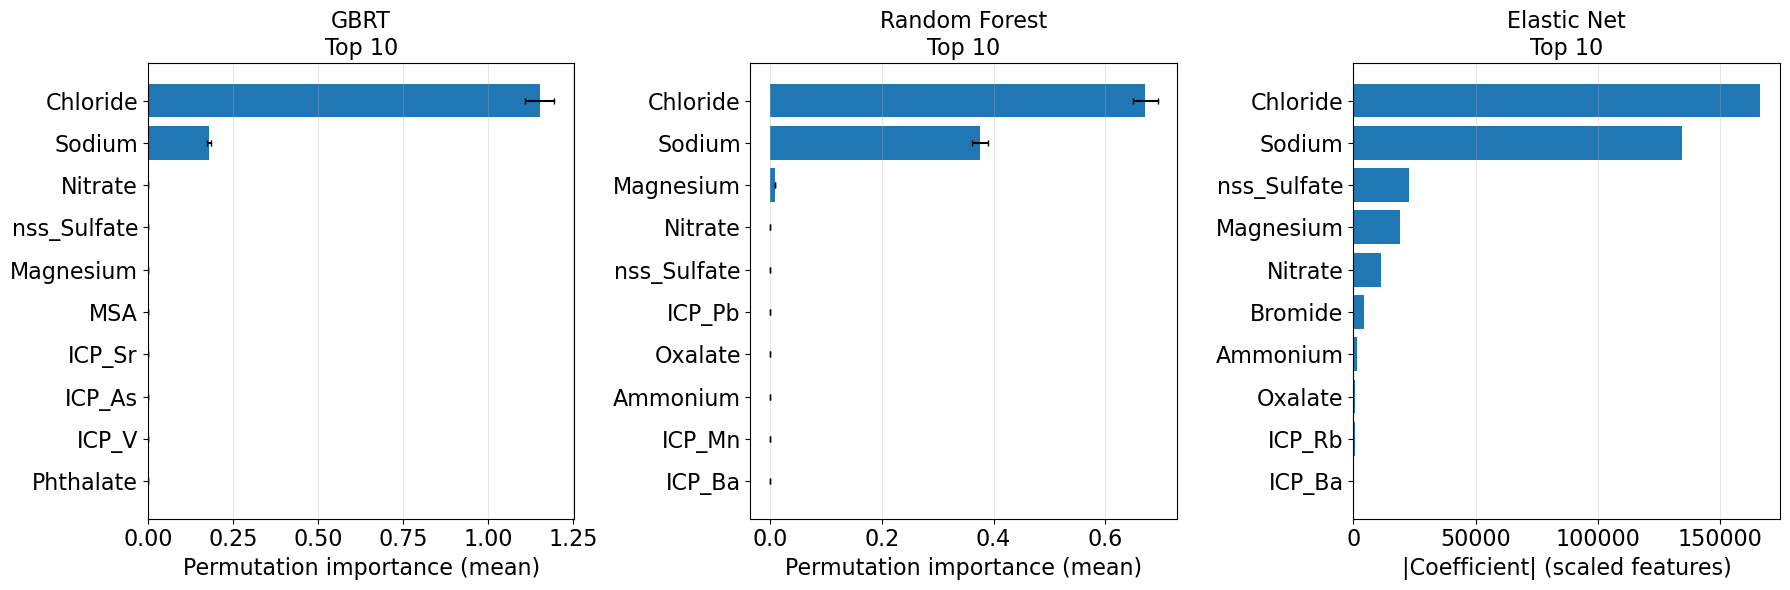

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_gbrt_rf_enet(imp_gbrt, imp_rf, imp_enet, top_n=15, figsize=(18, 6)):
    """
    imp_gbrt: columns ['species','perm_importance_mean'] (+ optional std)
    imp_rf:   columns ['species','perm_importance_mean'] (+ optional std)
    imp_enet: columns ['species','abs_coef'] (or you can pass 'coef' and take abs)
    """

    # --- prep each model table to a common schema: metric_name, metric_value, metric_std(optional) ---
    g = imp_gbrt.copy()
    g = g.sort_values("perm_importance_mean", ascending=False).head(top_n)
    g = g.rename(columns={"perm_importance_mean": "value"})
    g["std"] = g["perm_importance_std"] if "perm_importance_std" in g.columns else np.nan

    r = imp_rf.copy()
    r = r.sort_values("perm_importance_mean", ascending=False).head(top_n)
    r = r.rename(columns={"perm_importance_mean": "value"})
    r["std"] = r["perm_importance_std"] if "perm_importance_std" in r.columns else np.nan

    e = imp_enet.copy()
    if "abs_coef" not in e.columns:
        e["abs_coef"] = e["coef"].abs()
    e = e.sort_values("abs_coef", ascending=False).head(top_n)
    e = e.rename(columns={"abs_coef": "value"})
    e["std"] = np.nan  # no std for coefficients unless you bootstrap

    panels = [
        ("GBRT", g, "Permutation importance (mean)"),
        ("Random Forest", r, "Permutation importance (mean)"),
        ("Elastic Net", e, "|Coefficient| (scaled features)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, (title, d, xlabel) in zip(axes, panels):
        d = d.sort_values("value", ascending=True)  # smallest on top
        y = np.arange(len(d))

        if d["std"].notna().any():
            ax.barh(y, d["value"].values, xerr=d["std"].values, capsize=2)
        else:
            ax.barh(y, d["value"].values)

        ax.set_yticks(y)
        ax.set_yticklabels(d["species"].values, fontsize=16)
        ax.set_title(f"{title}\nTop {top_n}", fontsize=16)
        ax.tick_params(axis="both", labelsize=16)  # hide yticks
        ax.set_xlabel(xlabel, fontsize=16)
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ---- call it ----
plot_gbrt_rf_enet(imp, imp_rf, imp_enet, top_n=10, figsize=(18, 6))


In [10]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# -----------------------------
# Common pre-step
# -----------------------------
df = enriched_df.copy()

time_col = "Time_Start"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# all species columns = everything except Time_Start
species_cols = [c for c in df.columns if c != time_col]

# numeric + missing handling
df[species_cols] = df[species_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# sort by time for time-aware CV
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# ---- define sea-salt columns to subtract (edit if you want) ----
sea_salt_candidates = [
    "Chloride", "Sodium", "Magnesium", "Bromide",
    "ICP_Sr"  # optional sea-salt tracer; keep or remove
]
ss_cols = [c for c in sea_salt_candidates if c in df.columns]

# total mass and nonSS mass target
df["Total_Mass"] = df[species_cols].sum(axis=1)
df["NonSS_Mass"] = df["Total_Mass"] - df[ss_cols].sum(axis=1)

# clip to avoid tiny negatives from rounding or bookkeeping
df["NonSS_Mass"] = df["NonSS_Mass"].clip(lower=0.0)

# predictors: exclude sea-salt columns
nonss_species_cols = [c for c in species_cols if c not in ss_cols]

X = df[nonss_species_cols].copy()
y = df["NonSS_Mass"].copy()

print("Sea-salt columns subtracted:", ss_cols)
print("Predictor count (nonSS species):", len(nonss_species_cols))
print("NonSS_Mass summary:\n", y.describe())

def cv_report(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"}
    out = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1, return_train_score=False)
    return {
        "R2 (mean)": out["test_r2"].mean(),
        "MAE (mean)": -out["test_mae"].mean(),
        "RMSE (mean)": -out["test_rmse"].mean(),
    }


Sea-salt columns subtracted: ['Chloride', 'Sodium', 'Magnesium', 'Bromide', 'ICP_Sr']
Predictor count (nonSS species): 26
NonSS_Mass summary:
 count       535.000000
mean      15347.255218
std       25035.680531
min         297.559600
25%        3154.593750
50%        6576.962500
75%       16441.941400
max      244739.502000
Name: NonSS_Mass, dtype: float64


In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt_nonss = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(random_state=42, loss="squared_error"))
])

print("GBRT NonSS CV:", cv_report(gbrt_nonss, X, y, n_splits=5))

gbrt_nonss.fit(X, y)

pi = permutation_importance(
    gbrt_nonss, X, y,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp_gbrt_nonss = pd.DataFrame({
    "species": nonss_species_cols,
    "perm_importance_mean": pi.importances_mean,
    "perm_importance_std": pi.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop species by permutation importance (GBRT, NonSS target):")
print(imp_gbrt_nonss.head(20).to_string(index=False))


GBRT NonSS CV: {'R2 (mean)': 0.8474055263521265, 'MAE (mean)': 3363.662269570541, 'RMSE (mean)': 9071.568923136101}

Top species by permutation importance (GBRT, NonSS target):
    species  perm_importance_mean  perm_importance_std
    Nitrate              0.596193             0.027745
nss_Sulfate              0.502075             0.022927
   Ammonium              0.008848             0.000507
     ICP_Co              0.005372             0.001114
      nssCa              0.002975             0.000163
     ICP_Ba              0.000827             0.000391
     ICP_Fe              0.000750             0.000373
     ICP_Cs              0.000521             0.000149
     ICP_Pb              0.000417             0.000224
    Oxalate              0.000359             0.000031
        MSA              0.000353             0.000093
     ICP_Mn              0.000182             0.000040
     ICP_Ti              0.000180             0.000063
  Phthalate              0.000118             0.00001

In [12]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_nonss = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_iter=500
    ))
])

print("HistGB NonSS CV:", cv_report(hgb_nonss, X, y, n_splits=5))

hgb_nonss.fit(X, y)

pi = permutation_importance(
    hgb_nonss, X, y,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp_hgb_nonss = pd.DataFrame({
    "species": nonss_species_cols,
    "perm_importance_mean": pi.importances_mean,
    "perm_importance_std": pi.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop species by permutation importance (HistGB, NonSS target):")
print(imp_hgb_nonss.head(20).to_string(index=False))


HistGB NonSS CV: {'R2 (mean)': 0.6919756783065675, 'MAE (mean)': 6274.744935225082, 'RMSE (mean)': 13012.960203364872}

Top species by permutation importance (HistGB, NonSS target):
    species  perm_importance_mean  perm_importance_std
    Nitrate              0.686532             0.030507
nss_Sulfate              0.303361             0.024659
     ICP_Co              0.059387             0.007508
       nssK              0.030592             0.005513
     ICP_Mn              0.022482             0.003815
      nssCa              0.019269             0.001737
     ICP_Mo              0.008147             0.001506
    Oxalate              0.005850             0.001162
   Ammonium              0.004662             0.000550
     ICP_Cd              0.004597             0.001139
     ICP_Fe              0.003225             0.000619
     ICP_Cr              0.002784             0.000842
     ICP_Ba              0.002765             0.000805
     ICP_Zn              0.002661             0.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# -----------------------------
# Assumes you've already built:
# df["NonSS_Mass"], nonss_species_cols, and X, y
# from the earlier NonSS setup.
# If not, run that setup block first.
# -----------------------------

def cv_report(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"}
    out = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1, return_train_score=False)
    return {
        "R2 (mean)": out["test_r2"].mean(),
        "MAE (mean)": -out["test_mae"].mean(),
        "RMSE (mean)": -out["test_rmse"].mean(),
    }

rf_nonss = Pipeline(steps=[
    ("scaler", StandardScaler()),  # requested scaling
    ("model", RandomForestRegressor(
        n_estimators=1000,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features="sqrt"
    ))
])

print("RF NonSS CV:", cv_report(rf_nonss, X, y, n_splits=5))

# Fit for global importance
rf_nonss.fit(X, y)

pi = permutation_importance(
    rf_nonss, X, y,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp_rf_nonss = pd.DataFrame({
    "species": nonss_species_cols,
    "perm_importance_mean": pi.importances_mean,
    "perm_importance_std": pi.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop species by permutation importance (RF, NonSS target):")
print(imp_rf_nonss.head(20).to_string(index=False))


RF NonSS CV: {'R2 (mean)': 0.6984716520604058, 'MAE (mean)': 6044.712214676665, 'RMSE (mean)': 12169.390335906819}

Top species by permutation importance (RF, NonSS target):
    species  perm_importance_mean  perm_importance_std
    Nitrate              0.300320             0.016946
nss_Sulfate              0.227603             0.010149
   Ammonium              0.038634             0.003061
    Oxalate              0.021425             0.001880
     ICP_Mn              0.017534             0.003484
     ICP_Mo              0.014923             0.002189
     ICP_Co              0.012675             0.001344
     ICP_Ba              0.011298             0.004076
  Phthalate              0.010508             0.003180
      nssCa              0.008246             0.000564
     ICP_Cs              0.007861             0.002864
     ICP_Zr              0.007527             0.002680
     ICP_Sn              0.005040             0.001725
     ICP_Zn              0.005010             0.001109
 

In [14]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Assumes you already built X, y, and nonss_species_cols from the NonSS setup.

def cv_report(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"}
    out = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1, return_train_score=False)
    return {
        "R2 (mean)": out["test_r2"].mean(),
        "MAE (mean)": -out["test_mae"].mean(),
        "RMSE (mean)": -out["test_rmse"].mean(),
    }

enet_nonss = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.01,      # tune if needed
        l1_ratio=0.5,    # 0=ridge-like, 1=lasso-like
        random_state=42,
        max_iter=50000
    ))
])

print("ElasticNet NonSS CV:", cv_report(enet_nonss, X, y, n_splits=5))

enet_nonss.fit(X, y)
coef = enet_nonss.named_steps["model"].coef_

imp_enet_nonss = pd.DataFrame({
    "species": nonss_species_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\nTop species by |coefficient| (ElasticNet, NonSS target):")
print(imp_enet_nonss.head(20).to_string(index=False))


ElasticNet NonSS CV: {'R2 (mean)': 0.999291002289719, 'MAE (mean)': 284.7236373869859, 'RMSE (mean)': 550.0278729387584}

Top species by |coefficient| (ElasticNet, NonSS target):
    species         coef     abs_coef
    Nitrate 13713.508540 13713.508540
nss_Sulfate 12312.483469 12312.483469
      nssCa  2156.186119  2156.186119
   Ammonium  1825.529266  1825.529266
    Oxalate   483.517465   483.517465
        MSA   276.638302   276.638302
  Phthalate   130.230552   130.230552
       nssK    77.731304    77.731304
     ICP_Fe    42.847775    42.847775
     ICP_Zn    39.934453    39.934453
     ICP_Pb    37.825072    37.825072
     ICP_Mo    35.615545    35.615545
     ICP_Mn    28.987274    28.987274
     ICP_As   -21.028655    21.028655
     ICP_Cu    19.887550    19.887550
     ICP_Al    16.733480    16.733480
     ICP_Cr    15.876918    15.876918
     ICP_Ba    13.866239    13.866239
     ICP_Rb    -9.222377     9.222377
     ICP_Co    -8.642921     8.642921


In [15]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Assumes X, y, nonss_species_cols are already defined.

tscv = TimeSeriesSplit(n_splits=5)

enetcv_nonss = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-4, 1, 40),
        cv=tscv,
        random_state=42,
        max_iter=100000
    ))
])

enetcv_nonss.fit(X, y)

best_alpha = enetcv_nonss.named_steps["model"].alpha_
best_l1 = enetcv_nonss.named_steps["model"].l1_ratio_
coef = enetcv_nonss.named_steps["model"].coef_

print("Best alpha:", best_alpha)
print("Best l1_ratio:", best_l1)

imp_enetcv_nonss = pd.DataFrame({
    "species": nonss_species_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\nTop species by |coefficient| (ElasticNetCV, NonSS target):")
print(imp_enetcv_nonss.head(20).to_string(index=False))

# Optional: show how many were effectively selected
print("\nNon-zero coefficients:", int((np.abs(coef) > 1e-12).sum()), "out of", len(coef))


Best alpha: 0.0001
Best l1_ratio: 0.9

Top species by |coefficient| (ElasticNetCV, NonSS target):
    species         coef     abs_coef
    Nitrate 13839.389272 13839.389272
nss_Sulfate 12363.447899 12363.447899
      nssCa  2135.387311  2135.387311
   Ammonium  1800.220838  1800.220838
    Oxalate   408.377825   408.377825
        MSA   271.223720   271.223720
  Phthalate   121.367416   121.367416
       nssK    73.603912    73.603912
     ICP_Zn    46.337972    46.337972
     ICP_Al    43.592683    43.592683
     ICP_Cr    21.066811    21.066811
     ICP_Fe    20.289686    20.289686
     ICP_Cu    16.173024    16.173024
     ICP_Cd     6.515161     6.515161
     ICP_Zr     4.256476     4.256476
     ICP_Mn     3.506400     3.506400
     ICP_As     3.148293     3.148293
     ICP_Ba     2.313260     2.313260
     ICP_Co     1.799204     1.799204
     ICP_Ti     1.405811     1.405811

Non-zero coefficients: 26 out of 26


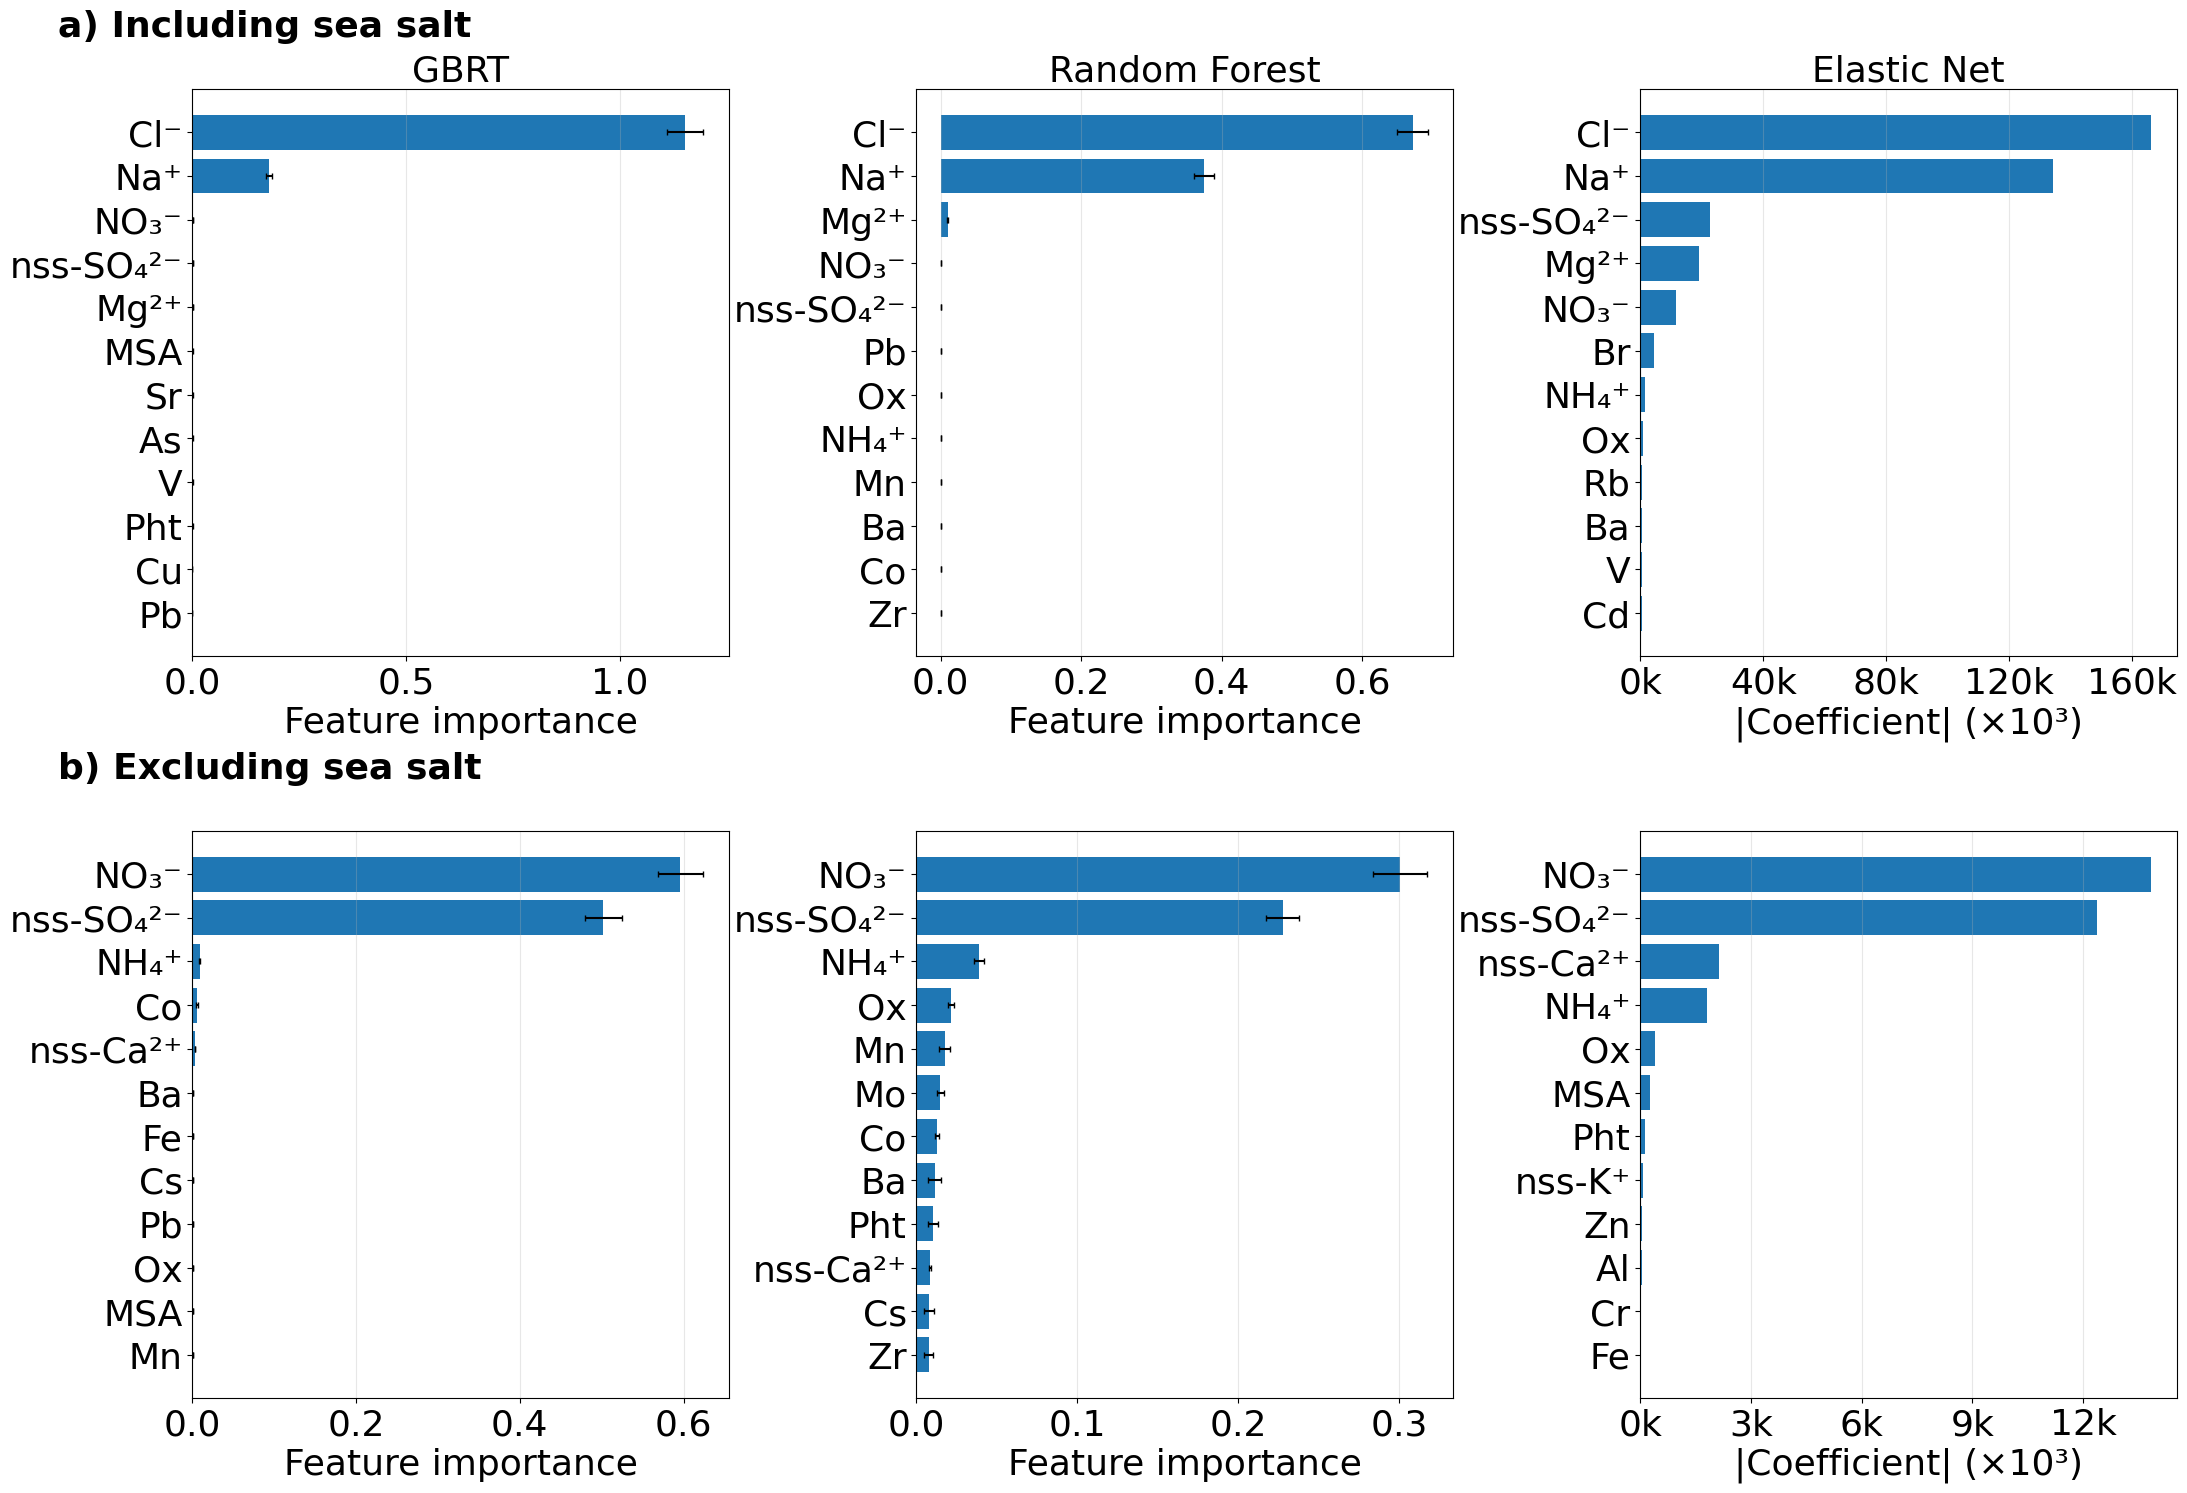

In [18]:
species_rename = {
    "Sodium": "Na⁺", "Chloride": "Cl⁻", "Nitrate": "NO₃⁻", "nss_Sulfate": "nss-SO₄²⁻", "nssK": "nss-K⁺",
    "Ammonium": "NH₄⁺", "Glutarate": "Glut", "Phthalate": "Pht", "Pyruvate": "Pyr", "Formate": "For",
    "Maleate": "MalE", "Adipate": "Adi", "Succinate": "Suc", "Glycolate": "Glyc", "Oxalate": "Ox",
    "Magnesium": "Mg²⁺", "Bromide": "Br", "ICP_B": "B", "ICP_Al": "Al", "ICP_Br": "Br", "ICP_Cd": "Cd",
    "ICP_Au": "Au", "ICP_V": "V", "ICP_Co": "Co", "ICP_Cu": "Cu", "ICP_Mn": "Mn", "ICP_Li": "Li",
    "ICP_Pt": "Pt", "ICP_Ti": "Ti", "ICP_K": "K", "ICP_Fe": "Fe", "ICP_Cr": "Cr", "ICP_Cs": "Cs",
    "ICP_Ni": "Ni", "ICP_Pb": "Pb", "ICP_Sr": "Sr", "ICP_Zn": "Zn", "ICP_I": "I", "ICP_U": "U",
    "ICP_Ag": "Ag", "ICP_Ge": "Ge", "ICP_Th": "Th", "ICP_W": "W", "ICP_Zr": "Zr", "ICP_Sb": "Sb",
    "ICP_Ir": "Ir", "ICP_Rh": "Rh", "ICP_Hg": "Hg", "nssCa": "nss-Ca²⁺", "ICP_Ce": "Ce", "ICP_Mo": "Mo",
    "ICP_Nb": "Nb", "ICP_Rb": "Rb", "ICP_Re": "Re", "ICP_Ta": "Ta", "ICP_Pd": "Pd", "ICP_Sn": "Sn",
    "ICP_Os": "Os", "ICP_As": "As", "ICP_Ba": "Ba"
}



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

def _prep_perm_imp(imp_df, top_n, rename_map=None):
    d = imp_df.copy()
    d = d.sort_values("perm_importance_mean", ascending=False).head(top_n)
    d = d.rename(columns={"perm_importance_mean": "value"})
    d["std"] = d["perm_importance_std"] if "perm_importance_std" in d.columns else np.nan
    d["label"] = d["species"].map(rename_map).fillna(d["species"]) if rename_map else d["species"]
    return d[["species", "label", "value", "std"]]

def _prep_enet_imp(enet_df, top_n, rename_map=None):
    d = enet_df.copy()
    if "abs_coef" not in d.columns:
        if "coef" in d.columns:
            d["abs_coef"] = d["coef"].abs()
        else:
            raise ValueError("ElasticNet importance DF must have 'abs_coef' or 'coef'.")
    d = d.sort_values("abs_coef", ascending=False).head(top_n)
    d = d.rename(columns={"abs_coef": "value"})
    d["std"] = np.nan
    d["label"] = d["species"].map(rename_map).fillna(d["species"]) if rename_map else d["species"]
    return d[["species", "label", "value", "std"]]

def plot_6panel_importance(
    imp_full_gbrt, imp_full_rf, imp_full_enet,
    imp_nonss_gbrt, imp_nonss_rf, imp_nonss_enet,
    top_n=10,
    rename_map=None,
    figsize=(22, 10),
    row_titles=("Including sea salt", "Excluding sea salt"),
    drop_list_row2=None,
    enet_axis_style="k"  # "k" or "sci"
):
    # ---- Prepare tables ----
    full_g = _prep_perm_imp(imp_full_gbrt, top_n, rename_map)
    full_r = _prep_perm_imp(imp_full_rf, top_n, rename_map)
    full_e = _prep_enet_imp(imp_full_enet, top_n, rename_map)

    non_g = _prep_perm_imp(imp_nonss_gbrt, top_n, rename_map)
    non_r = _prep_perm_imp(imp_nonss_rf, top_n, rename_map)
    non_e = _prep_enet_imp(imp_nonss_enet, top_n, rename_map)

    if drop_list_row2:
        non_g = non_g[~non_g["species"].isin(drop_list_row2)]
        non_r = non_r[~non_r["species"].isin(drop_list_row2)]
        non_e = non_e[~non_e["species"].isin(drop_list_row2)]

    # Order: top row (full), bottom row (nonSS)
    panels = [
        ("GBRT", full_g, "Feature importance"),
        ("Random Forest", full_r, "Feature importance"),
        ("Elastic Net", full_e, "|Coefficient|"),
        ("GBRT", non_g, "Feature importance"),
        ("Random Forest", non_r, "Feature importance"),
        ("Elastic Net", non_e, "|Coefficient|"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for i, (title, d, xlabel) in enumerate(panels):
        ax = axes[i]

        dplot = d.sort_values("value", ascending=True).copy()
        y = np.arange(len(dplot))

        if dplot["std"].notna().any():
            ax.barh(y, dplot["value"].values, xerr=dplot["std"].values, capsize=2)
        else:
            ax.barh(y, dplot["value"].values)

        ax.set_yticks(y)
        ax.set_yticklabels(dplot["label"].values, fontsize=26)
        ax.set_xlabel(xlabel, fontsize=26)
        ax.grid(True, axis="x", alpha=0.3)
        ax.tick_params(axis="both", labelsize=26)

        # ---- Titles only on first row ----
        if i < 3:
            ax.set_title(title, fontsize=26)
        else:
            ax.set_title("")  # remove title on second row

        # ---- Fix Elastic Net x-axis tick overlap ----
        if title == "Elastic Net":
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            if enet_axis_style == "k":
                ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f}k"))
                ax.set_xlabel("|Coefficient| (×10³)", fontsize=26)
            elif enet_axis_style == "sci":
                ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
                ax.xaxis.get_offset_text().set_size(26)
            else:
                raise ValueError("enet_axis_style must be 'k' or 'sci'.")

    # Row labels (left side)
    axes[0].text(-0.25, 1.08, row_titles[0], transform=axes[0].transAxes,
                 fontsize=26, fontweight="bold", va="bottom")
    axes[3].text(-0.25, 1.08, row_titles[1], transform=axes[3].transAxes,
                 fontsize=26, fontweight="bold", va="bottom")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.35)
    plt.show()


# ---- CALL EXAMPLE ----
plot_6panel_importance(
    imp_full_gbrt=imp,
    imp_full_rf=imp_rf,
    imp_full_enet=imp_enet,
    imp_nonss_gbrt=imp_gbrt_nonss,
    imp_nonss_rf=imp_rf_nonss,
    imp_nonss_enet=imp_enetcv_nonss,
    top_n=12,
    rename_map=species_rename,
    figsize=(22, 15),
    row_titles=("a) Including sea salt", "b) Excluding sea salt"),
    enet_axis_style="k"
)
